
# ***Customer Churn Prediction using Machine Learning***

### **Objective** : To build a machine learning model that predicts customer churn and helps businesses identify at-risk customers to improve retention strategies.

### **Approch**
#### Cleaned and preprocessed telecom dataset
#### Performed feature engineering (usage ratios, call patterns)
#### Trained: Logistic Regression ,Random Forest
#### Evaluated using: Accuracy,Recall,Confusion Matrix

In [ ]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv("churn-bigml-20.csv")

In [3]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Account length,667.0,102.841079,40.819480,1.00,76.00,102.00,128.000,232.00
Area code,667.0,436.157421,41.783305,408.00,408.00,415.00,415.000,510.00
Number vmail messages,667.0,8.407796,13.994480,0.00,0.00,0.00,20.000,51.00
Total day minutes,667.0,180.948126,55.508628,25.90,146.25,178.30,220.700,334.30
Total day calls,667.0,100.937031,20.396790,30.00,87.50,101.00,115.000,165.00
Total day charge,667.0,30.761769,9.436463,4.40,24.86,30.31,37.520,56.83
Total eve minutes,667.0,203.355322,49.719268,48.10,171.05,203.70,236.450,361.80
Total eve calls,667.0,100.476762,18.948262,37.00,88.00,101.00,113.000,168.00
Total eve charge,667.0,17.285262,4.226160,4.09,14.54,17.31,20.095,30.75
Total night minutes,667.0,199.685307,49.759931,23.20,167.95,201.60,231.500,367.70


In [6]:
df.duplicated().value_counts()

False    667
Name: count, dtype: int64

In [7]:
df.nunique()

State                      51
Account length            179
Area code                   3
International plan          2
Voice mail plan             2
Number vmail messages      37
Total day minutes         562
Total day calls           100
Total day charge          562
Total eve minutes         557
Total eve calls            94
Total eve charge          528
Total night minutes       568
Total night calls          96
Total night charge        453
Total intl minutes        132
Total intl calls           17
Total intl charge         132
Customer service calls      9
Churn                       2
dtype: int64

In [8]:
df['total_minutes'] = (df['Total day minutes'] 
                      +df['Total eve charge'] +
                      df['Total night charge']+ 
                      df['Total intl minutes'])


In [9]:
df['total_calls'] = (df['Total day calls'] 
                      +df['Total eve calls'] +
                      df['Total night calls']+ 
                      df['Total intl calls'])

In [10]:
df['average_call_duration'] = df['total_minutes']/df['total_calls']

In [11]:
df['day_usage_ratio'] = df["Total day minutes"] / df["total_minutes"]

In [12]:
df["intl_usage_ratio"] = df['Total intl minutes']/df['total_minutes']

In [13]:
df['high_complaint'] = (df['Customer service calls'] > 3).astype(int)

In [14]:
df['calls_per_day'] = df['total_calls']/df['Account length']

In [15]:
df['intl_plan_heavy_user']=(df['International plan']== 'Yes') & (df["Total intl minutes"] > 10).astype(int)

In [16]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn', 'total_minutes', 'total_calls', 'average_call_duration',
       'day_usage_ratio', 'intl_usage_ratio', 'high_complaint',
       'calls_per_day', 'intl_plan_heavy_user'],
      dtype='object')

In [17]:
df = df.drop(
    columns=[
         'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge'])
        
        

In [18]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total eve minutes', 'Total eve calls',
       'Total night minutes', 'Total night calls', 'Total intl minutes',
       'Total intl calls', 'Customer service calls', 'Churn', 'total_minutes',
       'total_calls', 'average_call_duration', 'day_usage_ratio',
       'intl_usage_ratio', 'high_complaint', 'calls_per_day',
       'intl_plan_heavy_user'],
      dtype='object')

In [19]:
df = df.drop(columns=[
    'Total day calls',
    'Total eve calls',
    'Total night calls',
    'Total intl calls'
])

In [20]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total eve minutes', 'Total night minutes', 'Total intl minutes',
       'Customer service calls', 'Churn', 'total_minutes', 'total_calls',
       'average_call_duration', 'day_usage_ratio', 'intl_usage_ratio',
       'high_complaint', 'calls_per_day', 'intl_plan_heavy_user'],
      dtype='object')

In [21]:
df = df.drop(columns = ['Area code', 'State'])

In [22]:
df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total eve minutes,Total night minutes,Total intl minutes,Customer service calls,Churn,total_minutes,total_calls,average_call_duration,day_usage_ratio,intl_usage_ratio,high_complaint,calls_per_day,intl_plan_heavy_user
0,117,No,No,0,184.5,351.6,215.8,8.7,1,False,232.80,271,0.859041,0.792526,0.037371,0,2.316239,False
1,65,No,No,0,129.1,228.5,208.8,12.7,4,True,170.62,337,0.506291,0.756652,0.074434,1,5.184615,False
2,161,No,No,0,332.9,317.8,160.6,5.4,4,True,372.54,301,1.237674,0.893595,0.014495,1,1.869565,False
3,111,No,No,0,110.4,137.3,189.6,7.7,2,False,138.30,316,0.437658,0.798265,0.055676,0,2.846847,False
4,49,No,No,0,119.3,215.1,178.7,11.1,1,False,156.72,317,0.494385,0.761230,0.070827,0,6.469388,False


In [23]:
df.columns = df.columns.str.replace(' ', "_")

In [24]:
df.head(10)

,Account_length,International_plan,Voice_mail_plan,Number_vmail_messages,Total_day_minutes,Total_eve_minutes,Total_night_minutes,Total_intl_minutes,Customer_service_calls,Churn,total_minutes,total_calls,average_call_duration,day_usage_ratio,intl_usage_ratio,high_complaint,calls_per_day,intl_plan_heavy_user
0,117,No,No,0,184.5,351.6,215.8,8.7,1,False,232.80,271,0.859041,0.792526,0.037371,0,2.316239,False
1,65,No,No,0,129.1,228.5,208.8,12.7,4,True,170.62,337,0.506291,0.756652,0.074434,1,5.184615,False
2,161,No,No,0,332.9,317.8,160.6,5.4,4,True,372.54,301,1.237674,0.893595,0.014495,1,1.869565,False
3,111,No,No,0,110.4,137.3,189.6,7.7,2,False,138.30,316,0.437658,0.798265,0.055676,0,2.846847,False
4,49,No,No,0,119.3,215.1,178.7,11.1,1,False,156.72,317,0.494385,0.761230,0.070827,0,6.469388,False
5,36,No,Yes,30,146.3,162.5,129.3,14.5,0,False,180.43,323,0.558607,0.810841,0.080364,0,8.972222,False
6,65,No,No,0,211.3,162.6,134.7,13.2,3,False,244.38,365,0.669534,0.864637,0.054014,0,5.615385,False
7,119,No,No,0,159.1,231.3,143.2,8.8,5,True,194.00,325,0.596923,0.820103,0.045361,1,2.731092,False
8,10,No,No,0,186.1,190.2,282.8,11.4,2,False,226.40,241,0.939419,0.821996,0.050353,0,24.100000,False
9,68,No,No,0,148.8,246.5,129.8,12.1,3,False,187.69,340,0.552029,0.792797,0.064468,0,5.000000,False


In [25]:
df['Churn']= df['Churn'].astype(int)
df['intl_plan_heavy_user']= df['intl_plan_heavy_user'].astype(int)

In [26]:
df["International_plan"]=df['International_plan'].map({"Yes":1,"No":0})
df["Voice_mail_plan"] = df["Voice_mail_plan"].map({"Yes":1, "No":0})

In [27]:
df.head(20)

,Account_length,International_plan,Voice_mail_plan,Number_vmail_messages,Total_day_minutes,Total_eve_minutes,Total_night_minutes,Total_intl_minutes,Customer_service_calls,Churn,total_minutes,total_calls,average_call_duration,day_usage_ratio,intl_usage_ratio,high_complaint,calls_per_day,intl_plan_heavy_user
0,117,0,0,0,184.5,351.6,215.8,8.7,1,0,232.80,271,0.859041,0.792526,0.037371,0,2.316239,0
1,65,0,0,0,129.1,228.5,208.8,12.7,4,1,170.62,337,0.506291,0.756652,0.074434,1,5.184615,0
2,161,0,0,0,332.9,317.8,160.6,5.4,4,1,372.54,301,1.237674,0.893595,0.014495,1,1.869565,0
3,111,0,0,0,110.4,137.3,189.6,7.7,2,0,138.30,316,0.437658,0.798265,0.055676,0,2.846847,0
4,49,0,0,0,119.3,215.1,178.7,11.1,1,0,156.72,317,0.494385,0.761230,0.070827,0,6.469388,0
5,36,0,1,30,146.3,162.5,129.3,14.5,0,0,180.43,323,0.558607,0.810841,0.080364,0,8.972222,0
6,65,0,0,0,211.3,162.6,134.7,13.2,3,0,244.38,365,0.669534,0.864637,0.054014,0,5.615385,0
7,119,0,0,0,159.1,231.3,143.2,8.8,5,1,194.00,325,0.596923,0.820103,0.045361,1,2.731092,0
8,10,0,0,0,186.1,190.2,282.8,11.4,2,0,226.40,241,0.939419,0.821996,0.050353,0,24.100000,0
9,68,0,0,0,148.8,246.5,129.8,12.1,3,0,187.69,340,0.552029,0.792797,0.064468,0,5.000000,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account_length          667 non-null    int64  
 1   International_plan      667 non-null    int64  
 2   Voice_mail_plan         667 non-null    int64  
 3   Number_vmail_messages   667 non-null    int64  
 4   Total_day_minutes       667 non-null    float64
 5   Total_eve_minutes       667 non-null    float64
 6   Total_night_minutes     667 non-null    float64
 7   Total_intl_minutes      667 non-null    float64
 8   Customer_service_calls  667 non-null    int64  
 9   Churn                   667 non-null    int64  
 10  total_minutes           667 non-null    float64
 11  total_calls             667 non-null    int64  
 12  average_call_duration   667 non-null    float64
 13  day_usage_ratio         667 non-null    float64
 14  intl_usage_ratio        667 non-null    fl

### Split feature and Target

In [29]:
X = df.drop('Churn',axis = 1)
y = df["Churn"]

### Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state= 42)

### Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

### Accuracy in Logistic regression

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_lr)

0.9253731343283582

# Classification report 

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_pred_lr, y_test))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       119
           1       0.67      0.67      0.67        15

    accuracy                           0.93       134
   macro avg       0.81      0.81      0.81       134
weighted avg       0.93      0.93      0.93       134



### Confusion Matrix


In [35]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_pred_lr,y_test))

[[114   5]
 [  5  10]]


### Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [39]:
y_pred_rf

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

### Accuracy in Random forest

In [38]:

accuracy_score(y_test,y_pred_rf)

0.9701492537313433

### Classificarion report for Random forest

In [40]:
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       119
           1       1.00      0.73      0.85        15

    accuracy                           0.97       134
   macro avg       0.98      0.87      0.91       134
weighted avg       0.97      0.97      0.97       134

[[119   0]
 [  4  11]]


### Feature Importance

In [41]:
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending = False)
importance

total_minutes             0.166852
Total_day_minutes         0.119635
Total_eve_minutes         0.100625
Customer_service_calls    0.070833
average_call_duration     0.070274
day_usage_ratio           0.059057
high_complaint            0.049744
Number_vmail_messages     0.045960
intl_usage_ratio          0.045724
Total_intl_minutes        0.045486
total_calls               0.044684
calls_per_day             0.038742
Total_night_minutes       0.035800
Account_length            0.035192
Voice_mail_plan           0.030657
intl_plan_heavy_user      0.024743
International_plan        0.015992
dtype: float64

### Overfitting Check

In [43]:
y_train_pred_rf = rf.predict(X_train)
print(f"Train Accuracy { accuracy_score(y_train,y_train_pred_rf)}")
print(f"Test Accuracy { accuracy_score(y_test,y_pred_rf)}")

Train Accuracy 1.0
Test Accuracy 0.9701492537313433


### Customer usage patterns , especially total and datetime usage, along with the customer service callls are the most significant features
### Random forest acheieved the best performace of 97% accuracy and strong recall, though slight overfit was observed dut to high training accuracy.

### Hyperparameter: hyperparameter tuning to reduce overfitting and improve model generalization, focusing on parameters like max_depth and min_samples_split.

In [47]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

In [48]:
rf.fit(X_train,y_train)
y_pred_rf_hp = rf.predict(X_test)

In [49]:
y_pred_rf_hp

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [57]:
## classification report and confusion matrix
print(classification_report(y_pred_rf_hp,y_test))
cm=confusion_matrix(y_pred_rf_hp,y_test)
print(cm)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       123
           1       0.73      1.00      0.85        11

    accuracy                           0.97       134
   macro avg       0.87      0.98      0.91       134
weighted avg       0.98      0.97      0.97       134

[[119   4]
 [  0  11]]


## Confusion Matrix

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt


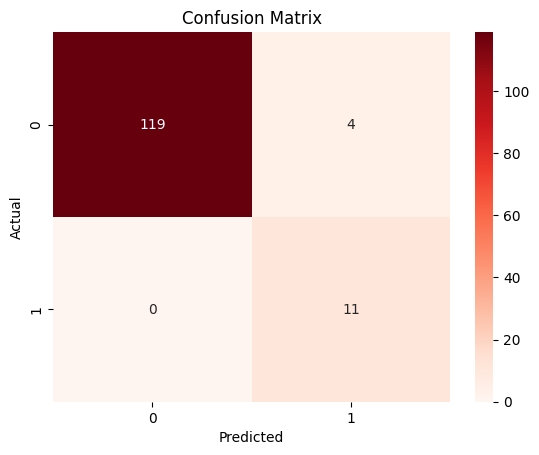

In [63]:
sns.heatmap(cm,annot= True,fmt="d",cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
accuracy_score(y_pred_rf_hp,y_test)

0.9701492537313433

In [67]:
## Importance
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance)

total_minutes             0.214581
Total_day_minutes         0.132851
Total_eve_minutes         0.091623
Customer_service_calls    0.089542
average_call_duration     0.078865
high_complaint            0.058828
Number_vmail_messages     0.045551
total_calls               0.040812
Voice_mail_plan           0.038285
day_usage_ratio           0.036911
intl_usage_ratio          0.035635
intl_plan_heavy_user      0.030370
Total_intl_minutes        0.029105
Total_night_minutes       0.022436
calls_per_day             0.020335
Account_length            0.017882
International_plan        0.016388
dtype: float64


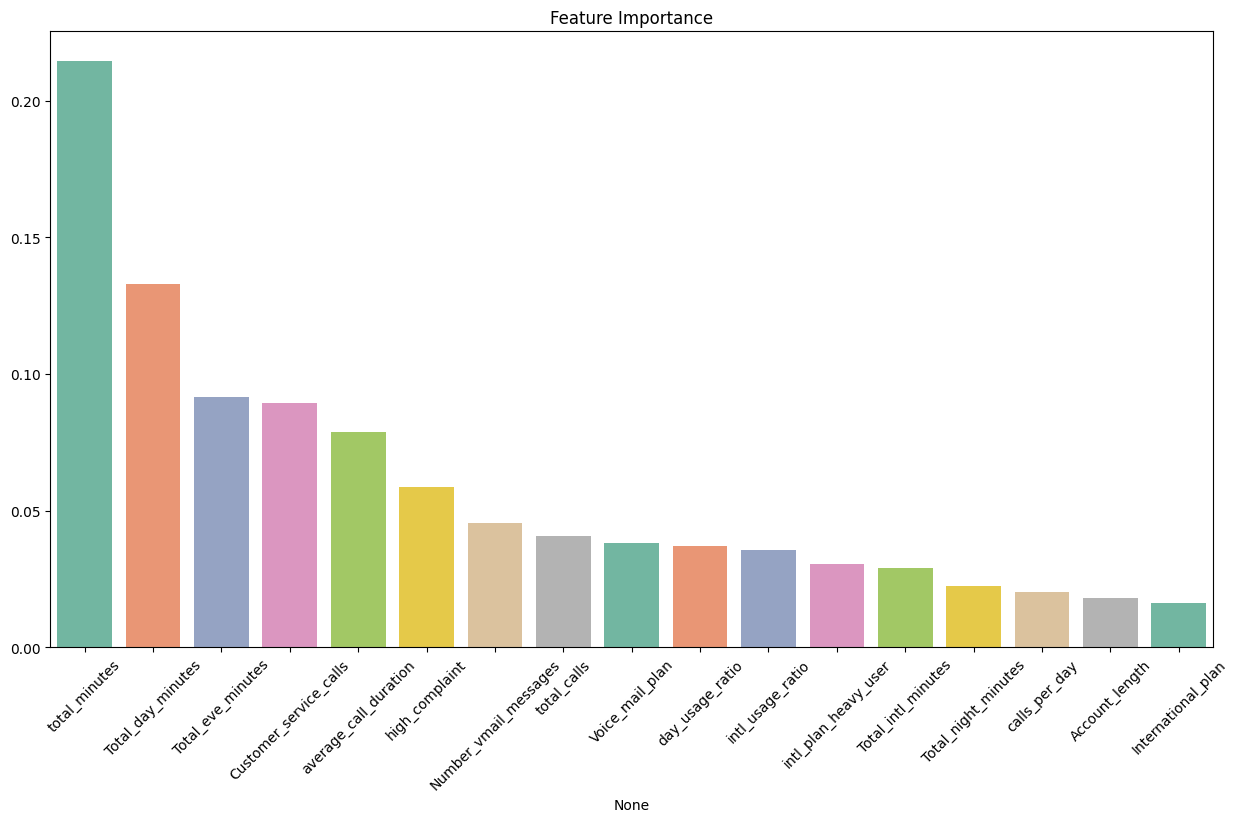

In [83]:
plt.figure(figsize=(15,8))
sns.barplot(x=importance.index, y=importance.values, palette='Set2', hue=importance.index, legend=False)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

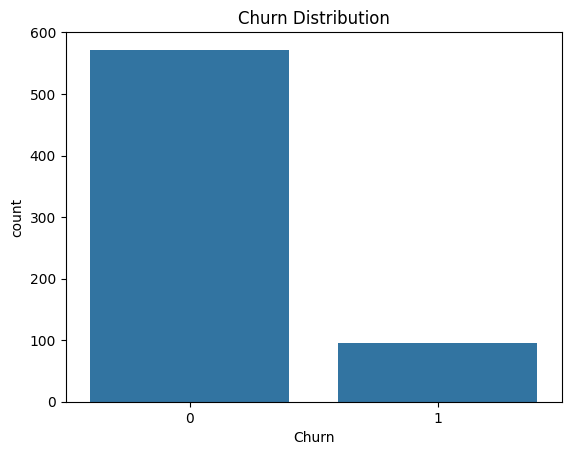

In [82]:
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

### After hyperparameter tuning, the Random Forest model achieved 100% recall for churn detection, ensuring no at-risk customers were missed, with a slight trade-off in precision

## **Result**
## **Best model**: Random Forest
## **Accuracy**: 97%
## **Recall (Churn)**: 100% 
## **No churn customers missed**

###  **The model can help companies proactively identify customers likely to churn and take retention actions, reducing potential revenue loss**